In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# Ćwiczenie 1

Program autoamtycznie wczytuje plik ekg1.txt jeżeli istnieje on w folderze data

In [45]:
load_filename = 'data/ekg1.txt' #path to the EKG data file 
df = pd.read_csv(load_filename, sep=' ', header=None)

# Display the first few rows of the DataFrame to verify it loaded correctly
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,106,335,228,-227,-59,291,-392,-45,443,372,908,395
1,106,335,228,-227,-59,291,-392,-45,443,372,908,395
2,106,325,219,-219,-60,284,492,837,239,372,908,405
3,86,306,219,-214,-55,274,487,832,240,404,179,-63
4,96,320,224,-195,-65,264,492,842,244,404,174,-62
5,106,325,219,-207,-62,274,492,832,235,414,189,-52
6,96,335,238,-214,-55,274,492,836,235,399,174,-67
7,96,325,228,-214,-70,288,492,831,230,399,174,-62
8,116,335,219,-209,-65,279,487,825,230,394,174,-67
9,101,335,233,-224,-50,279,492,835,240,394,164,-86


In [46]:
# Check the shape of the DataFrame to understand how many rows and columns it contains
df.shape

(5000, 12)

In [88]:
def plot_signals(df: pd.DataFrame, signal_start: float, signal_end: float, signal_frequency: float, y_scale: float) -> None:
    """Plots the signals from the DataFrame based on the specified parameters.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_start (float): The starting point of the signal to plot (in seconds).
    signal_end (float): The ending point of the signal to plot (in seconds).
    signal_frequency (float): The frequency of the signal (in Hz).
    y_scale (float): The scale for the y-axis limits.
    """
    plt.close('all')
    fig, axes = plt.subplots(df.shape[1], 1, figsize=(16, df.shape[1] * 4), sharex=True)

    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)

    if df.shape[1] == 1:
        axes = [axes]  # Ensure axes is always a list for consistent indexing
    # Plot each channel on separate chart
    for i in range(df.shape[1]):
        sns.lineplot(data=df[signal_start:signal_end], x=df[signal_start:signal_end].index, y=df.columns[i], ax=axes[i], color='pink')
        axes[i].set_ylim(-y_scale, y_scale)
        axes[i].set_title(f"Signal {i}")
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

In [ ]:
def save_signals(df: pd.DataFrame, signal_start: float, signal_end: float, signal_frequency: float, filename: str) -> None:
    """Saves the specified range of signals from the DataFrame to a CSV file.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_start (float): The starting point of the signal to save (in seconds).
    signal_end (float): The ending point of the signal to save (in seconds).
    signal_frequency (float): The frequency of the signal (in Hz).
    filename (str): The name of the file to save the signals to.
    """
    signal_start *= signal_frequency # Convert signal start and end from seconds to sample indices
    signal_end *= signal_frequency
    signal_start = int(signal_start) # Convert signal start and end to integers for indexing
    signal_end = int(signal_end)
    df[signal_start:signal_end].to_csv(filename, index=False, sep=' ', header=None)

### Interaktywny widżet do wyswitlania oraz zapiswyania fragmentów sygnału EKG

<ol>
  <li>Update: Aktualizuje widget (np. po wyborze nowego zakresu)</li>
  <li>Save: Zapisze wycinek sygnału do pliku o wybranej nazwie</li>
  <li>Frequency: Pozwala okreslic częstoliwość</li>
  <li>Start/End: pozwalją okreslić wycinek sygnału do podglądu w połaczeniu z cześtosliwoscią (początek sygnału * czestoliwość, koniec sygnału * częstoliwość) </li>
  <li>Y axis scale: Okresla skale osi Y (np. dla Y axis scale 100 oś Y ma zakres od -100 do +100)</li>
  <li>Filename: Nazwa pliku do którego my być zpisnay sygnał</li>
</ol> 


In [ ]:
def create_signal_widget(df: pd.DataFrame, signal_frequency: float) -> None:
    """Creates an interactive widget to visualize and save the signals from the DataFrame.
    Parameters:
    df (pd.DataFrame): The DataFrame containing the signal data.
    signal_frequency (float): The frequency of the signal (in Hz)."""
    #initialize widgets
    out = widgets.Output() 

    max_value = df.max().max() #get the maximum value in the DataFrame for scaling
    max_value = min(max_value + 100, max_value * 2) #add some padding to the maximum value for better visualization
    #declare input widgets
    start_input = widgets.BoundedFloatText(
        value=0,
        min=0,
        max=df.shape[0] / signal_frequency, #default to the full length of the signal in seconds
        step=0.1,
        description='Start:',
        layout=widgets.Layout(width='200px')
    )
    end_input = widgets.BoundedFloatText(
        value=min(5, df.shape[0] / signal_frequency), #default to the full length of the signal in seconds
        min=0,
        max=df.shape[0] / signal_frequency,
        step=0.1,
        description='End:',
        layout=widgets.Layout(width='200px')
    )

    freq_input = widgets.BoundedIntText(
        value=signal_frequency,
        min=1,
        max=10000,
        step=1,
        description='Frequency:',
        layout=widgets.Layout(width='200px')
    )
    y_scale_input = widgets.BoundedFloatText(
        value=max_value, #default to the maximum value in the DataFrame for scaling
        min=0.1,
        max=10000,
        step=0.1,
        description='Y axis scale:',
        layout=widgets.Layout(width='200px')
    )
    filename_input = widgets.Text(
        value='ekg_signals.txt',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )

    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    #define button click events
    def update_plot():
        with out:
            clear_output(wait=True) 
            signal_frequency = freq_input.value
            plot_signals(df, start_input.value, end_input.value, signal_frequency, y_scale_input.value)

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        signal_frequency = freq_input.value
        save_signals(df, start_input.value, end_input.value, signal_frequency, filename_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, freq_input, start_input, end_input, y_scale_input, filename_input])

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

In [156]:
create_signal_widget(df, 1000)

Output()

# Ćwiczenie 2

In [ ]:

#Generate sine wave signal for testing
freq = 50
time = np.arange(0, 65536, 1/freq)
signal = np.sin(2 * np.pi * 5 * time)

df_signal = pd.DataFrame(signal, columns=['Signal'])

create_signal_widget(df_signal, signal_frequency=freq)

HTML(value='')

Output()

In [ ]:
def plot_spectrum(frequencies: np.ndarray, amplitudes: np.ndarray) -> None:
    """Plots the spectrum of a signal.
    Parameters:
    frequencies (np.ndarray): The frequency vector.
    amplitudes (np.ndarray): The amplitude vector."""

    plt.close('all')
    plt.figure(figsize=(16,4))
    plt.plot(frequencies, amplitudes)
    plt.xlabel("Frequency[Hz]")
    plt.ylabel("Amplitude")
    plt.show()

In [ ]:
def calculate_spectrum(signal: np.ndarray, freq: float) -> tuple:
    """Calculates the spectrum of a signal.
    Parameters:
    signal (np.ndarray): The input signal.
    freq (float): The frequency for spectrum calculation.
    Returns:
    tuple: A tuple containing the frequencies and amplitudes."""
    n = len(signal)
    fft_res = np.fft.fft(signal)
    amplit = np.abs(fft_res)/n
    freqs = np.fft.fftfreq(n, d=1/freq)
    mask = (freqs >= 0) & (freqs <= freq/2)
    return freqs[mask], amplit[mask]

In [ ]:
def calculate_and_plot_spectrum(signal: np.ndarray, freq: float) -> None:
    """Calculates and plots the spectrum of a signal.
    Parameters:
    signal (np.ndarray): The input signal.
    freq (float): The frequency for spectrum calculation."""

    frequencies, amplitudes = calculate_spectrum(signal, freq=freq)
    plot_spectrum(frequencies, amplitudes)

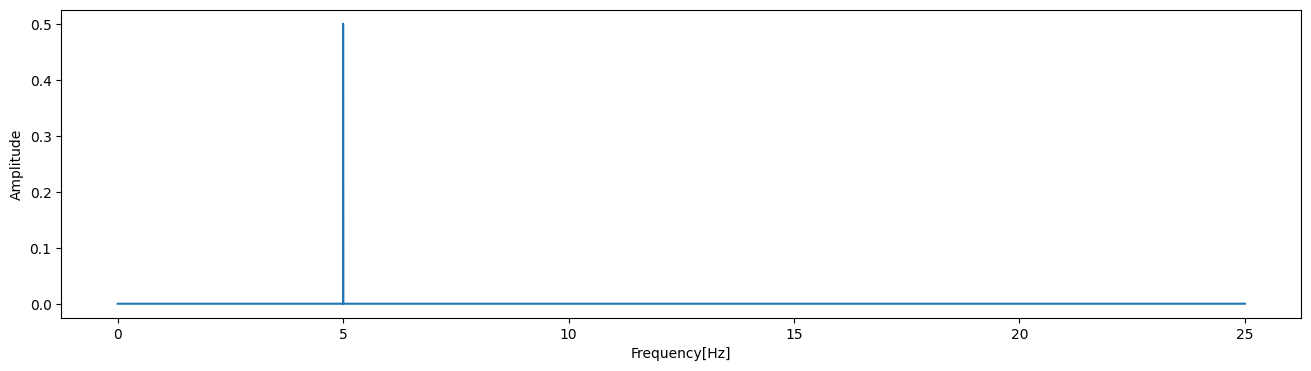

In [127]:
calculate_and_plot_spectrum(signal, freq=freq)

In [ ]:
def generate_mixed_signals(freqs: list, amplitudes: list, fs: float, N: int) -> tuple:
    """Generates a mixed signal with specified frequencies and amplitudes.
    Parameters:
    freqs (list): The frequencies of the sinusoidal components (in Hz).
    amplitudes (list): The amplitudes of the sinusoidal components.
    fs (float): The sampling frequency (in Hz).
    N (int): The number of samples.
    Returns:
    tuple: A tuple containing the time vector and the generated signal."""
    time = np.arange(N) / fs
    signal = sum(a * np.sin(2 * np.pi * f * time) for f, a in zip(freqs, amplitudes))
    return time, signal

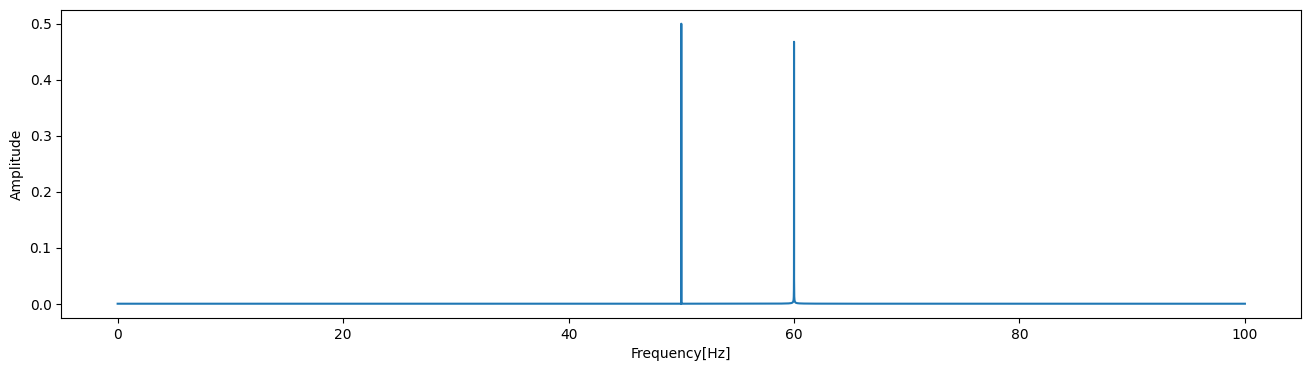

In [177]:
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
calculate_and_plot_spectrum(signal, freq=200)

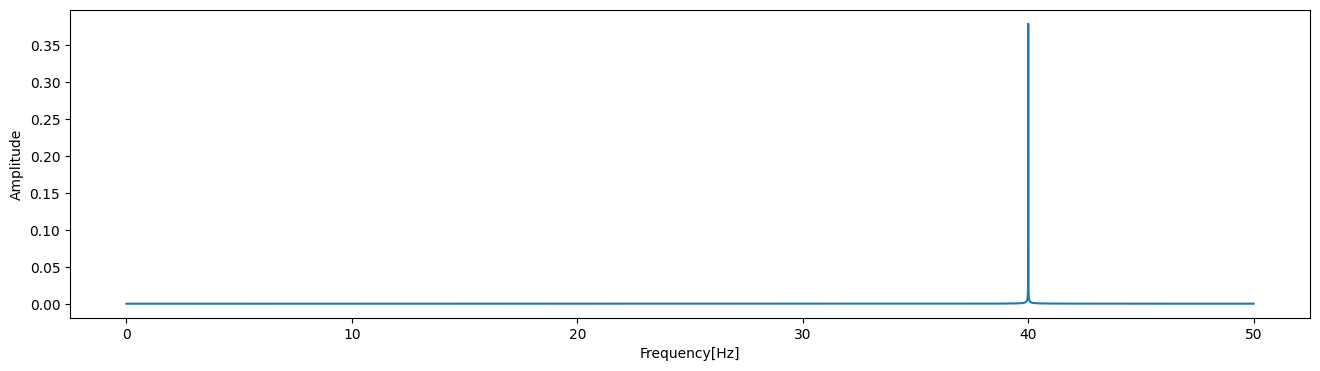

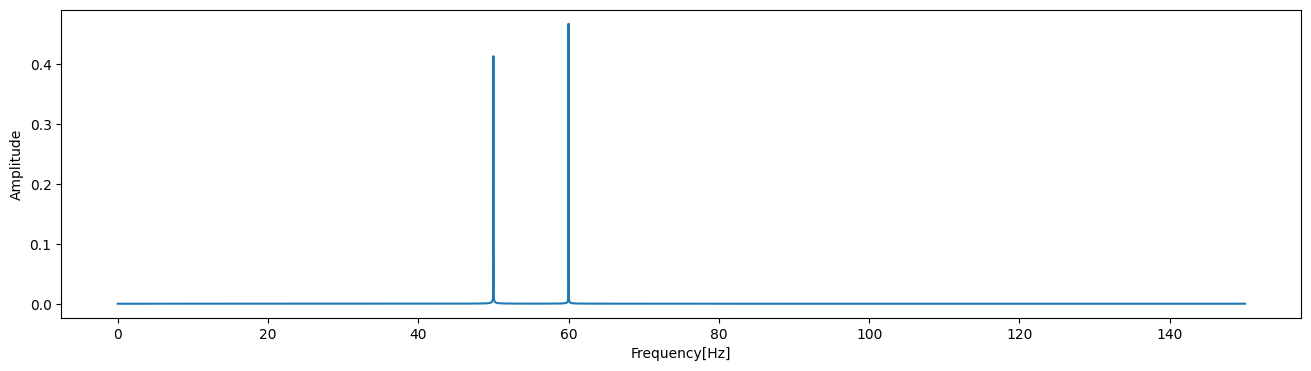

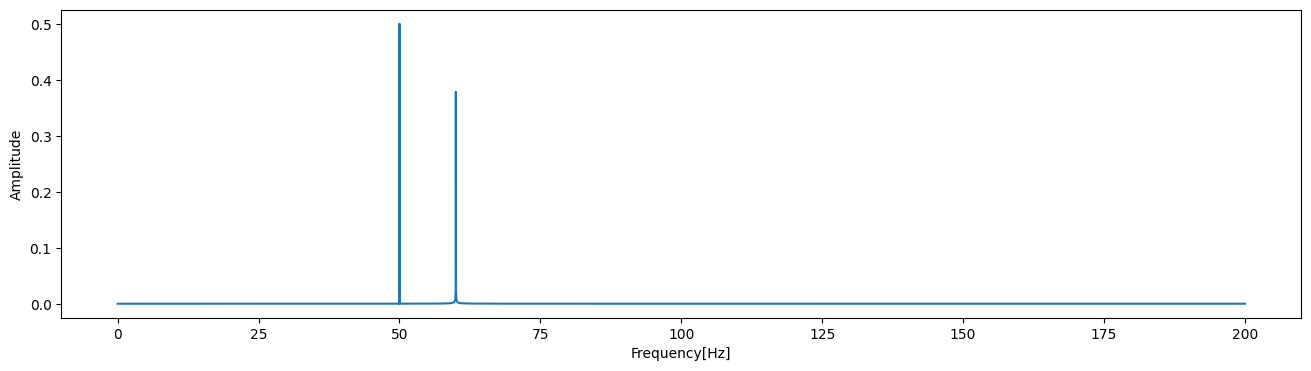

In [178]:
time,signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=100, N=65536)
calculate_and_plot_spectrum(signal, freq=100)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=300, N=65536)
calculate_and_plot_spectrum(signal, freq=300)
time, signal = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=400, N=65536)
calculate_and_plot_spectrum(signal, freq=400)

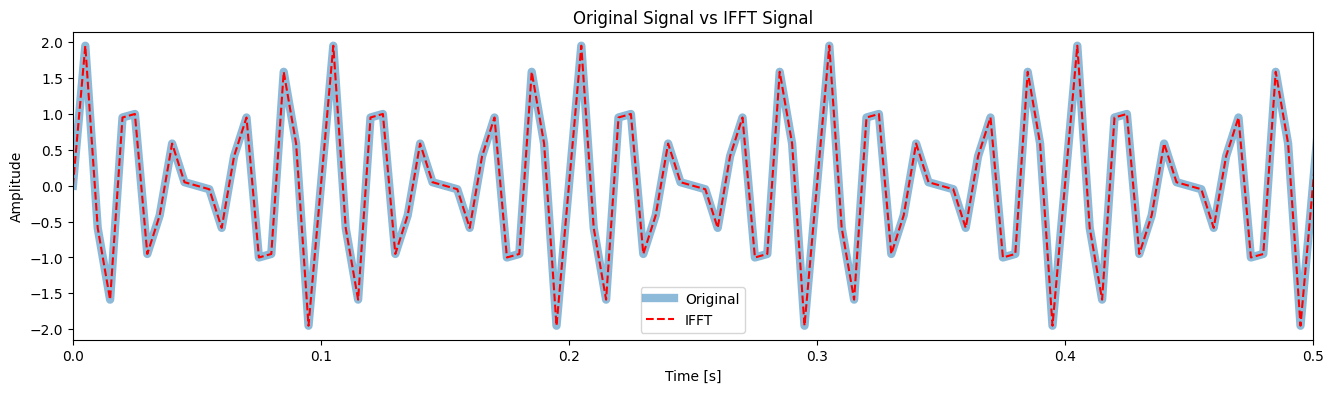

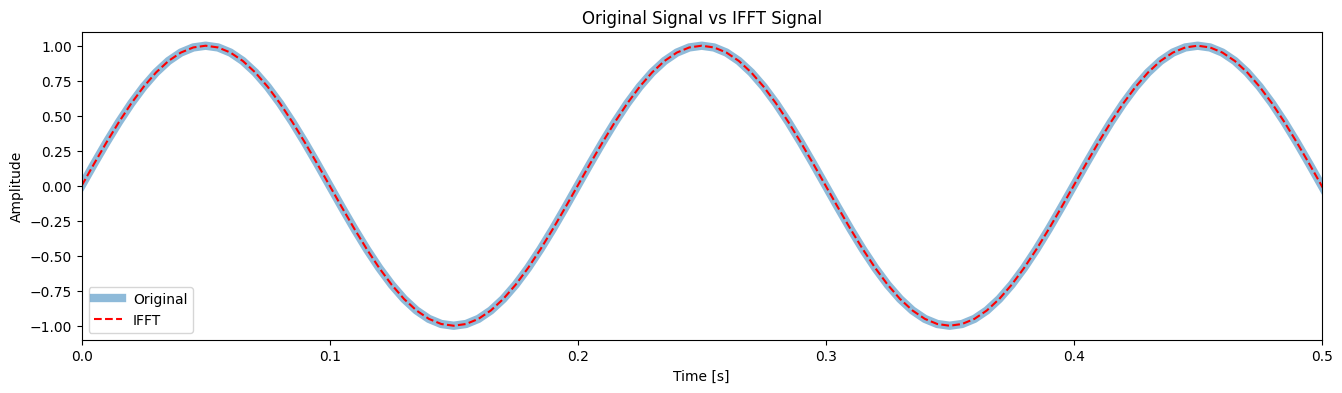

In [ ]:
def plot_ifft(time: np.ndarray, signal: np.ndarray) -> None:
    """Plots the original signal and the IFFT signal for comparison.
    Parameters:
    time (np.ndarray): The time vector.
    signal (np.ndarray): The original input signal."""
    N = len(signal)
    
    fft_result = np.fft.fft(signal)
    ifft_result = np.fft.ifft(fft_result)
    ifft_real = np.real(ifft_result)    
    

    plt.figure(figsize=(16, 4))
    
    plt.plot(time, signal, label='Original', linewidth=6, alpha=0.5) 
    plt.plot(time, ifft_real, 'r--', label='IFFT') 
    
    plt.xlim(0, 0.5)
    plt.title("Original Signal vs IFFT Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()
time, signal1 = generate_mixed_signals(freqs=[50, 60], amplitudes=[1, 1], fs=200, N=65536)
plot_ifft(time, signal1)
signal_sin=np.sin(2 * np.pi * 5 * time)
plot_ifft(time, signal=signal_sin)

# Ćwiczenie 3

In [57]:
df_ekg = pd.read_csv('data/ekg100.txt', sep='\s+', header=None)
df_ekg.columns = ['Amplitude'] 
df_ekg.head(10)

,Amplitude
0,-0.145
1,-0.145
2,-0.145
3,-0.145
4,-0.145
5,-0.145
6,-0.145
7,-0.145
8,-0.120
9,-0.135


In [132]:
create_signal_widget(df_ekg, signal_frequency=1000)

HTML(value='')

Output()

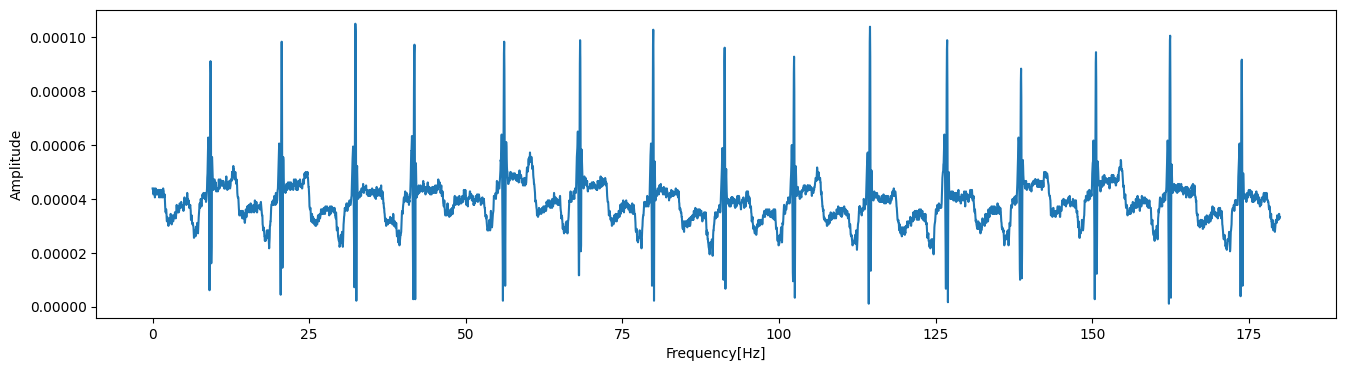

In [133]:
signal_ekg = df_ekg[1000:10000].to_numpy()
calculate_and_plot_spectrum(signal_ekg,360)

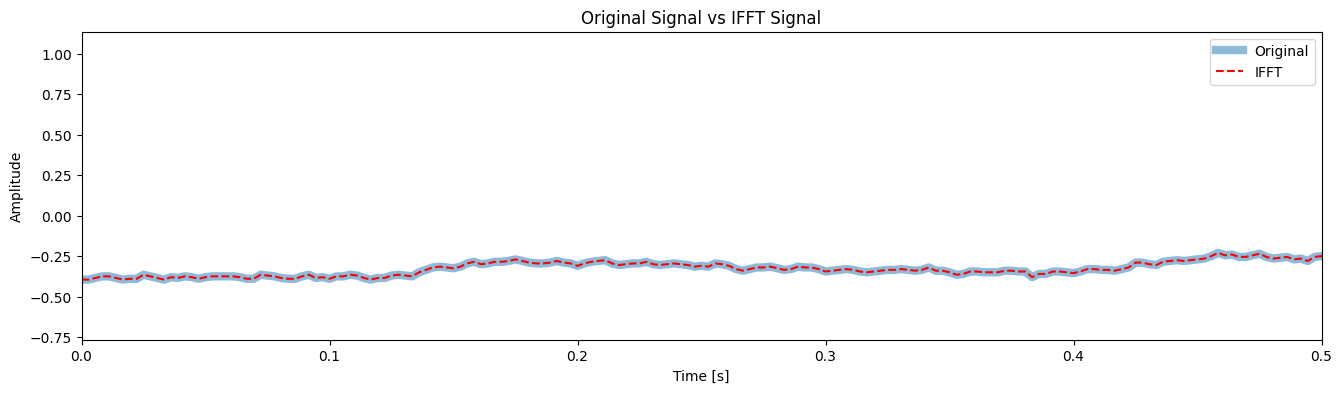

In [180]:
# get time for EKG signal
fs_ekg = 360 
time_ekg = np.arange(len(signal_ekg)) / fs_ekg

plot_ifft(time_ekg, signal_ekg)

# Ćwiczenie 4

In [61]:
from scipy.signal import butter, filtfilt

In [101]:
df_ekg_noise = pd.read_csv('data/ekg_noise.txt', sep='\s+', header=None)
df_ekg_noise.columns = ['time','signal']
df_ekg_noise.head(10)

,time,signal
0,0.000000,-0.325000
1,0.002778,-0.273038
2,0.005556,-0.268038
3,0.008333,-0.320000
4,0.011111,-0.391962
5,0.013889,-0.396962
6,0.016667,-0.340000
7,0.019444,-0.263038
8,0.022222,-0.258038
9,0.025000,-0.315000


In [102]:
df_ekg_noise = df_ekg_noise[['signal']] # We don't need time column for plotting, so we can just use the signal column

In [151]:
create_signal_widget(df_ekg_noise, signal_frequency=360)

HTML(value='')

Output()

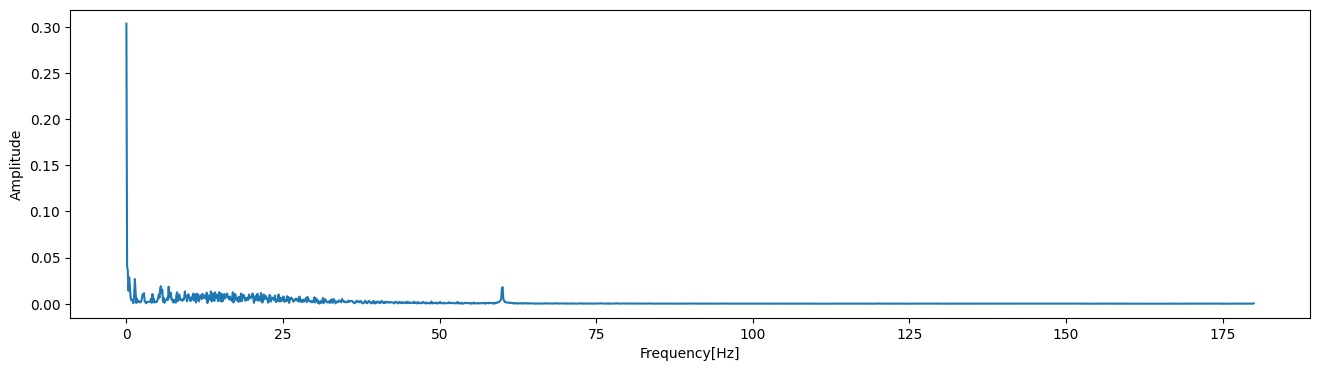

In [134]:
signal_ekg_noise = df_ekg_noise['signal'].to_numpy()
calculate_and_plot_spectrum(signal_ekg_noise, freq=360)

In [ ]:
def butter_lowpass_filter(data: np.ndarray, cutoff: float = 60, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth lowpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    cutoff (float): The cutoff frequency of the lowpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

def butter_highpass_filter(data: np.ndarray, cutoff: float = 5, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth highpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    cutoff (float): The cutoff frequency of the highpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, data)

In [ ]:
def plot_filtered_signal(original_signal: np.ndarray, filtered_signal: np.ndarray) -> None:
    """Plots the original signal and the filtered signal for comparison.
    parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter."""
    
    plt.figure(figsize=(16, 4))
    plt.plot(original_signal, label='Original', linewidth=6, alpha=0.5) 
    plt.plot(filtered_signal, label='Filtered') 
    plt.title("Original Signal vs Filtered Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

In [ ]:
def save_filtered_signal(original_signal: np.ndarray, filtered_signal: np.ndarray, filename: str, time_start: float = 0, time_end: float = None) -> None:
    """Saves the original signal and the filtered signal to a CSV file for comparison.
    Parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter.
    filename (str): The name of the CSV file to save the signals.
    time_start (float): The start time for the segment to be saved.
    time_end (float): The end time for the segment to be saved. If None, saves until the end of the signals."""
    if time_end is None:
        time_end = min(len(original_signal), len(filtered_signal))
    df_filtered = pd.DataFrame({
        'Original': original_signal[time_start:time_end],
        'Filtered': filtered_signal[time_start:time_end]
    })
    df_filtered.to_csv(filename, index=False)

### Interaktywny widżet do wyswitlania oraz zapiswyania fragmentów filtrowanego oraz orgirnalnego sygnału

<ol>
  <li>Update: Aktualizuje widget (np. po wyborze nowego zakresu)</li>
  <li>Save: Zapisze wycinek sygnału do pliku o wybranej nazwie</li>
  <li>Start/End: pozwalją okreslić wycinek sygnału (w sekundach) </li>
  <li>Y axis scale: Okresla skale osi Y (np. dla Y axis scale 100 oś Y ma zakres od -100 do +100)</li>
  <li>Filename: Nazwa pliku do którego my być zpisnay sygnał</li>
</ol> 


In [ ]:
def create_filtered_signal_widget(original_signal: np.ndarray, filtered_signal: np.ndarray) -> None:
    """Creates an interactive widget to visualize and save the original and filtered signals.
    Parameters:
    original_signal (np.ndarray): The original input signal before filtering.
    filtered_signal (np.ndarray): The signal after applying the filter."""
    
    #initialize widgets
    out = widgets.Output() 

    #declare input widgets
    start_input = widgets.BoundedIntText(
        value=0,
        min=0,
        max=original_signal.shape[0],
        step=0.1,
        description='Start:',
        layout=widgets.Layout(width='200px')
    )
    end_input = widgets.BoundedIntText(
        value=max(5, original_signal.shape[0]), #default to the full length of the signal 
        min=0,
        max=original_signal.shape[0],
        step=0.1,
        description='End:',
        layout=widgets.Layout(width='200px')
    )

    y_scale_input = widgets.BoundedFloatText(
        value=original_signal.max(), #default to the maximum value in the DataFrame for scaling
        min=0.1,
        max=10000,
        step=0.1,
        description='Y axis scale:',
        layout=widgets.Layout(width='200px')
    )
    filename_input = widgets.Text(
        value='ekg_filtered_signals.csv',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )

    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    #define button click events
    def update_plot():
        with out:
            clear_output(wait=True) 
            plot_filtered_signal(original_signal[int(start_input.value):int(end_input.value)], filtered_signal[int(start_input.value):int(end_input.value)])

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        save_filtered_signal(original_signal, filtered_signal, "results/" + filename_input.value, time_start=start_input.value, time_end=end_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, start_input, end_input, y_scale_input, filename_input])

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

In [ ]:
filtered_low = butter_lowpass_filter(signal_ekg_noise, cutoff=60, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_low)

Output()

In [173]:
filtered_high = butter_highpass_filter(signal_ekg_noise, cutoff=5, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_high)

Output()

In [174]:
filtered_high = butter_highpass_filter(filtered_low, cutoff=5, fs=360, order=4)
create_filtered_signal_widget(filtered_low, filtered_high)

Output()

In [ ]:

def butter_band_filter(data: np.ndarray, lowcut: float = 5, highcut: float = 30, fs: float = 360, order: int = 4) -> np.ndarray:
    """Applies a Butterworth bandpass filter to the input data.
    Parameters:
    data (np.ndarray): The input signal to be filtered.
    lowcut (float): The lower cutoff frequency of the bandpass filter (in Hz).
    highcut (float): The upper cutoff frequency of the bandpass filter (in Hz).
    fs (float): The sampling frequency of the input signal (in Hz).
    order (int): The order of the Butterworth filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

In [175]:
filtered_band = butter_band_filter(signal_ekg_noise, lowcut=5, highcut=60, fs=360, order=4)
create_filtered_signal_widget(signal_ekg_noise, filtered_band)

Output()